# EE446 - TinyML - Assignment 2

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

2026-06-03 23:33:51.142489: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-03 23:33:51.143945: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-03 23:33:51.162637: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-03 23:33:51.162668: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-03 23:33:51.162686: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

## Reading Data

In [2]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [3]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [4]:
## INSERT YOUR CODE HERE ##
data = data.drop(columns=['land', 'urgent', 'numfailedlogins', 'numoutboundcmds'])

##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [5]:
## INSERT YOUR CODE HERE ##
data['attack'] = data['attack'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

In [6]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [7]:
## INSERT YOUR CODE HERE ##
le = LabelEncoder()
for col in ['protocoltype', 'service', 'flag', 'attack']:
    data[col] = le.fit_transform(data[col])

In [8]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [9]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

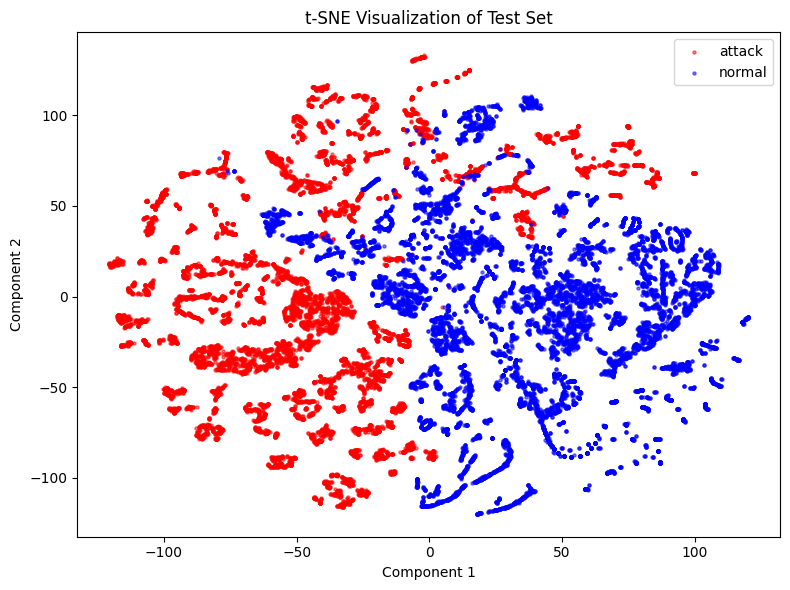

In [10]:
from sklearn.manifold import TSNE
## INSERT YOUR CODE HERE ##

# Apply t-SNE to reduce X_test to 2D
tsne = TSNE(n_components=2, random_state=42)
X_test_tsne = tsne.fit_transform(X_test)

# Flatten y_test for indexing
y_test_flat = y_test.flatten()

# Plot: red = attack (0), blue = normal (1)
plt.figure(figsize=(8, 6))
plt.scatter(X_test_tsne[y_test_flat == 0, 0], X_test_tsne[y_test_flat == 0, 1],
            c='red', label='attack', alpha=0.5, s=5)
plt.scatter(X_test_tsne[y_test_flat == 1, 0], X_test_tsne[y_test_flat == 1, 1],
            c='blue', label='normal', alpha=0.5, s=5)
plt.title('t-SNE Visualization of Test Set')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend()
plt.tight_layout()
plt.show()

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

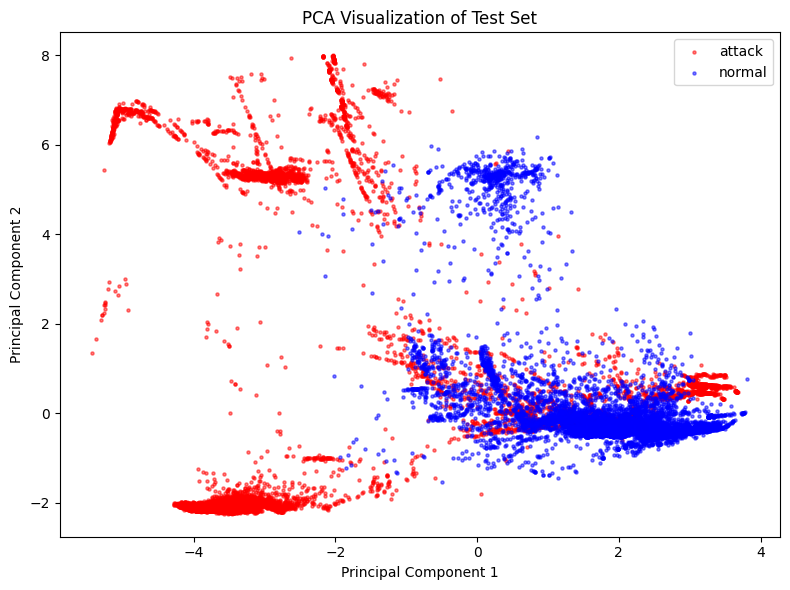

In [11]:
from sklearn.decomposition import PCA
## INSERT YOUR CODE HERE ##

# Apply PCA to reduce X_test to 2D
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

# Plot: red = attack (0), blue = normal (1)
plt.figure(figsize=(8, 6))
plt.scatter(X_test_pca[y_test_flat == 0, 0], X_test_pca[y_test_flat == 0, 1],
            c='red', label='attack', alpha=0.5, s=5)
plt.scatter(X_test_pca[y_test_flat == 1, 0], X_test_pca[y_test_flat == 1, 1],
            c='blue', label='normal', alpha=0.5, s=5)
plt.title('PCA Visualization of Test Set')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

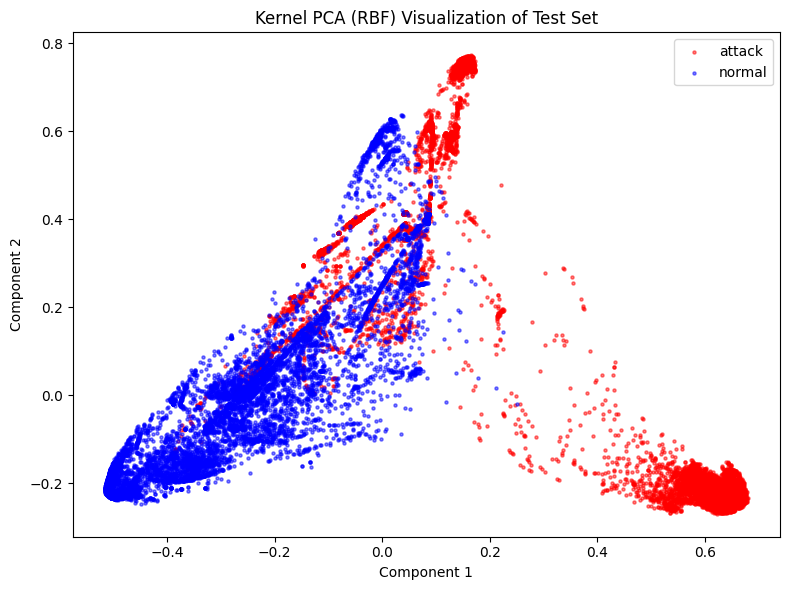

In [12]:
from sklearn.decomposition import KernelPCA
## INSERT YOUR CODE HERE ##

# Apply KernelPCA with rbf kernel to reduce X_test to 2D
kpca = KernelPCA(n_components=2, kernel='rbf')
X_test_kpca = kpca.fit_transform(X_test)

# Plot: red = attack (0), blue = normal (1)
plt.figure(figsize=(8, 6))
plt.scatter(X_test_kpca[y_test_flat == 0, 0], X_test_kpca[y_test_flat == 0, 1],
            c='red', label='attack', alpha=0.5, s=5)
plt.scatter(X_test_kpca[y_test_flat == 1, 0], X_test_kpca[y_test_flat == 1, 1],
            c='blue', label='normal', alpha=0.5, s=5)
plt.title('Kernel PCA (RBF) Visualization of Test Set')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend()
plt.tight_layout()
plt.show()

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure to include two neurons and softmax activation in the output layer of your DNN.

In [13]:
# Define the DNN model
base_model = Sequential([
    ## INSERT YOUR CODE HERE ##
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')
])

2026-06-03 23:34:27.780625: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-03 23:34:27.781063: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [14]:
## INSERT YOUR CODE HERE ##

# Compile the model
base_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

base_model.summary()

# Train the model
history = base_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               4992      
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 2)                 66        
                                                                 
Total params: 15394 (60.13 KB)
Trainable params: 15394 (60.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
355/355 [==============================] - 1s 1ms/step - loss: 0.0453 - accuracy: 0.9875 - val_loss: 0.0132 - val_accuracy: 0.9943
Epoch 2/10

##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

788/788 [==============================] - 1s 626us/step
Classification Report (base_model):
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11726
      normal       1.00      1.00      1.00     13469

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Confusion Matrix (base_model):
[[11718     8]
 [   49 13420]]


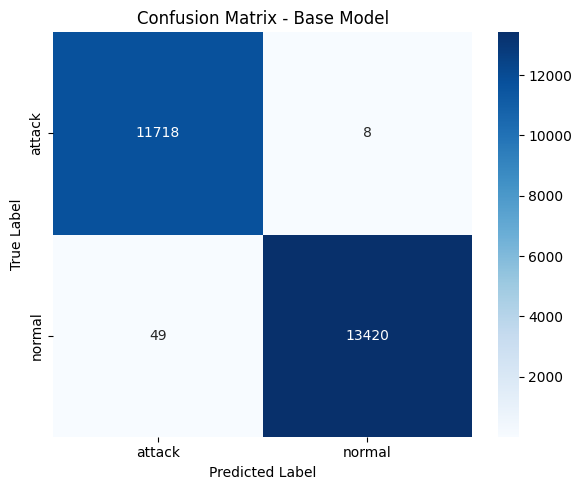

In [15]:
## INSERT YOUR CODE HERE ##

# Get predictions from the base model
y_pred_probs = base_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Flatten y_test for evaluation
y_test_eval = y_test.flatten()

# Classification report
print("Classification Report (base_model):")
print(classification_report(y_test_eval, y_pred, target_names=['attack', 'normal']))

# Confusion matrix
cm = confusion_matrix(y_test_eval, y_pred)
print("Confusion Matrix (base_model):")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['attack', 'normal'],
            yticklabels=['attack', 'normal'])
plt.title('Confusion Matrix - Base Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [16]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement Dynamic Range Quantization on the base_model. Designate the resulting quantized ML model as tflite_quant_model.

In [17]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

## INSERT YOUR CODE HERE ##

# Create a TFLite converter from the Keras model
converter = tf.lite.TFLiteConverter.from_keras_model(base_model)

# Apply Dynamic Range Quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model
tflite_quant_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmparoy1wx6/assets


INFO:tensorflow:Assets written to: /tmp/tmparoy1wx6/assets
2026-06-03 23:34:32.944951: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-03 23:34:32.944982: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-03 23:34:32.945248: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmparoy1wx6
2026-06-03 23:34:32.946023: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-03 23:34:32.946031: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmparoy1wx6
2026-06-03 23:34:32.947761: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-06-03 23:34:32.948268: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-03 23:34:32.972257: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

In [18]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 221.01 KB
Quantized model size: 18.48 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

Classification Report (tflite_quant_model):
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11726
      normal       1.00      1.00      1.00     13469

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Confusion Matrix (tflite_quant_model):
[[11719     7]
 [   49 13420]]


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


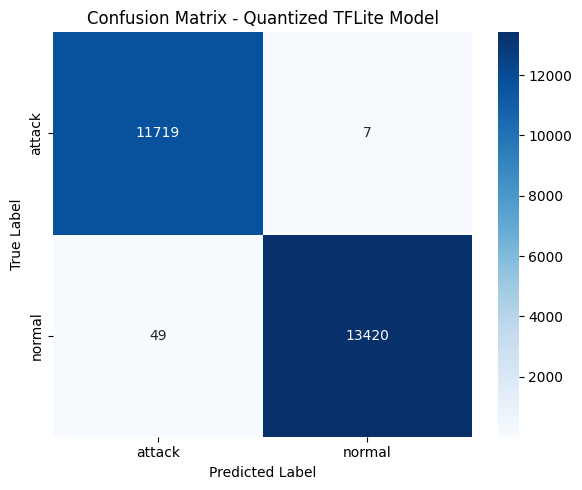

In [19]:
## INSERT YOUR CODE HERE ##

# Load the quantized TFLite model and set up interpreter
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()

# Get input and output tensor details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Run inference on each test sample
y_pred_quant = []
for i in range(len(X_test)):
    # Prepare input: must be float32 and shaped [1, num_features]
    input_data = np.array([X_test[i]], dtype=np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    y_pred_quant.append(np.argmax(output_data))

y_pred_quant = np.array(y_pred_quant)

# Classification report
print("Classification Report (tflite_quant_model):")
print(classification_report(y_test_eval, y_pred_quant, target_names=['attack', 'normal']))

# Confusion matrix
cm_quant = confusion_matrix(y_test_eval, y_pred_quant)
print("Confusion Matrix (tflite_quant_model):")
print(cm_quant)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_quant, annot=True, fmt='d', cmap='Blues',
            xticklabels=['attack', 'normal'],
            yticklabels=['attack', 'normal'])
plt.title('Confusion Matrix - Quantized TFLite Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Converting tflite_model to C and create the header file

In [20]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [21]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [22]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

Xtest = X_test[0:5,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 5;
const unsigned int X_test_dim2 = 38;

const float X_test[5][38] = {
    -0.11024922321249885, -0.12470615670462065, 1.3931828317609012, 
    0.7511112872365361, -0.007625109943309639, -0.0048343423057570474, 
    -0.08948642202040107, -0.09507567152556495, 1.2356940323701657, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.7257784945454897, -0.35434285002584825, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, 3.4741184775599305, 
    -1.5437496079957045, 0.3915636300872831, -0.002765789814281515, 
    -0.06855302025511306, -0.38310818187794965, -0.20026454391970344, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.18856898114475226, 0.6528228780141483, -0.110249

In [23]:
ytest=y_test[0:5]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 5;
const unsigned int y_test_dim2 = 1;

const uint8_t y_test[5][1] = {
    1, 0, 1, 1, 0
};



In [24]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

# Convert WITHOUT quantization
converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
tflite_float_model = converter.convert()

with open('model_float.tflite', 'wb') as f:
    f.write(tflite_float_model)

print(f"Float model size: {len(tflite_float_model) / 1024:.2f} KB")

# Generate the header file
hex_array = [format(val, '#04x') for val in tflite_float_model]
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
header_str = c_writer.create_header(c_model, "network_model")

with open('network_model_float.h', 'w') as file:
    file.write(header_str)

print("Done! Copy network_model_float.h to your Arduino folder as network_model.h")

INFO:tensorflow:Assets written to: /tmp/tmp75_zkapv/assets


INFO:tensorflow:Assets written to: /tmp/tmp75_zkapv/assets


Float model size: 62.59 KB
Done! Copy network_model_float.h to your Arduino folder as network_model.h


2026-06-04 00:12:37.118922: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-04 00:12:37.118993: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-04 00:12:37.119444: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp75_zkapv
2026-06-04 00:12:37.120076: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-04 00:12:37.120092: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp75_zkapv
2026-06-04 00:12:37.123337: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-04 00:12:37.156467: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp75_zkapv
2026-06-04 00:12:37.162786: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 43333 m

In [26]:
Xtest2 = X_test[5:15,:]
print(c_writer.create_array(Xtest2.reshape(10,38),"float","X_test"))

ytest2 = y_test[5:15].flatten()
print(c_writer.create_array(ytest2,"uint8_t","y_test"))

const unsigned int X_test_dim1 = 10;
const unsigned int X_test_dim2 = 38;

const float X_test[10][38] = {
    -0.11024922321249885, 2.219311849644404, -1.1761894520278895, 
    0.7511112872365361, -0.00775508609027698, -0.004908199878489922, 
    -0.08948642202040107, -0.09507567152556495, -0.8092618187059747, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.6209824629911074, -0.10653031654754139, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, 0.5876098410858317, 
    0.7343425609306344, 1.1684219150619566, 0.9773040843755113, 
    -0.3861460041139426, -0.4801968475158174, -0.28910340026287856, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.11024922321249